<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Visualizing Errors](04.03-Errorbars.ipynb) | [Contents](Index.ipynb) | [Histograms, Binnings, and Density](04.05-Histograms-and-Binnings.ipynb) >

# Density and Contour Plots / 密度图与等高线图

Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.
There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.
This section looks at several examples of using these. We'll start by setting up the notebook for plotting and importing the functions we will use: 

🐍 Matplotlib 提供了三个函数来解决这个问题：用 plt.contour 画等高线图、用 plt.contourf 画带有填充色的等高线图（filled contour plot）的色彩、用 plt.imshow 显示图形。

In [1]:
# %matplotlib inline
import matplotlib.pyplot as plt
# plt.style.use('seaborn-white')
import numpy as np

## Visualizing a Three-Dimensional Function / 三维函数的可视化

We'll start by demonstrating a contour plot using a function $z = f(x, y)$, using the following particular choice for $f$ (we've seen this before in [Computation on Arrays: Broadcasting](02.05-Computation-on-arrays-broadcasting.ipynb), when we used it as a motivating example for array broadcasting):

In [29]:
def f(x, y):
    return np.sin(x) ** 20 + np.cos(1000 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.
The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.
Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

🐍 等高线图可以用 plt.contour 函数来创建。它需要三个参数：x 轴、y 轴、z 轴三个坐标轴的网格数据。x 轴与 y 轴表示图形中的位置，而 z 轴将通过等高线的等级来表示。

🐍 用 np.meshgrid 函数来准备这些数据可能是最简单的方法，它可以从一维数组构建二维网格数据

In [9]:
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

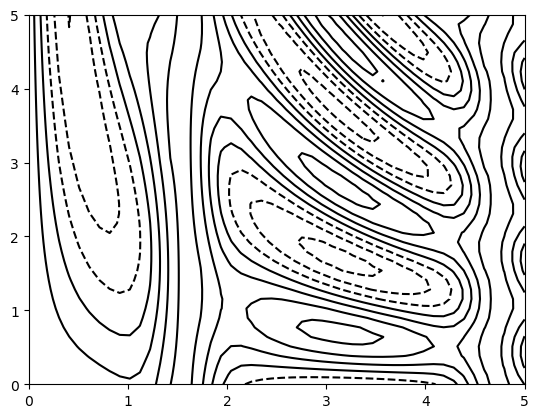

In [30]:
# 🐍 plt.contour(x, y, z)

plt.contour(X, Y, Z, colors='black');

Notice that by default when a single color is used, negative values are represented by dashed lines, and positive values by solid lines.
Alternatively, the lines can be color-coded by specifying a colormap with the ``cmap`` argument.
Here, we'll also specify that we want more lines to be drawn—20 equally spaced intervals within the data range:

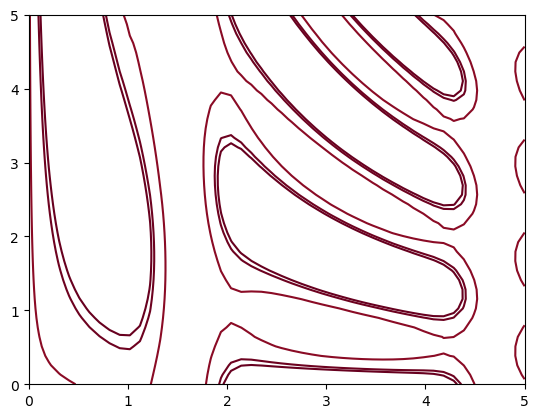

In [11]:
# 🐍 高度20等份， cmap参数定义颜色

plt.contour(X, Y, Z, [0, 0.1, 0.5, 10], cmap='RdGy');

Here we chose the ``RdGy`` (short for *Red-Gray*) colormap, which is a good choice for centered data.
Matplotlib has a wide range of colormaps available, which you can easily browse in IPython by doing a tab completion on the ``plt.cm`` module:
```
plt.cm.<TAB>
```

Our plot is looking nicer, but the spaces between the lines may be a bit distracting.
We can change this by switching to a filled contour plot using the ``plt.contourf()`` function (notice the ``f`` at the end), which uses largely the same syntax as ``plt.contour()``.

🐍 通过 plt.contourf()函数来填充等高线图（需要注意结尾有字母 f），它的语法和 plt.contour() 是一样的

Additionally, we'll add a ``plt.colorbar()`` command, which automatically creates an additional axis with labeled color information for the plot:

🐍 可以通过 plt.colorbar() 命令自动创建一个表示图形各种颜色对应标签信息的颜色条

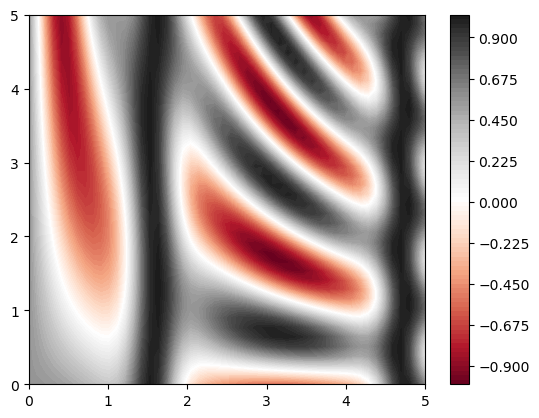

In [35]:
# plt.contourf(x, y, z) + plt.colorbar()

plt.contourf(X, Y, Z, 100, cmap='RdGy')
plt.colorbar();

The colorbar makes it clear that the black regions are "peaks," while the red regions are "valleys."

One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.
This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

🐍 通过 plt.imshow()函数来处理，它可以将二维数组渲染成渐变图

The following code shows this:

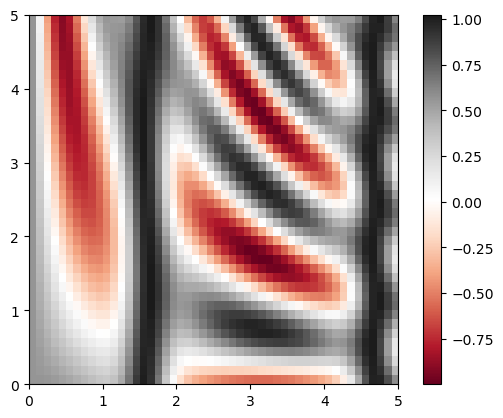

In [37]:
# plt.imshow(Z, )

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
# plt.axis(aspect='image');

There are a few potential gotchas with ``imshow()``, however:

- ``plt.imshow()`` doesn't accept an *x* and *y* grid, so you must manually specify the *extent* [*xmin*, *xmax*, *ymin*, *ymax*] of the image on the plot.
- ``plt.imshow()`` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
- ``plt.imshow()`` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, ``plt.axis(aspect='image')`` to make *x* and *y* units match.


🐍 plt.imshow() 不支持用 x 轴和 y 轴数据设置网格，而是必须通过 extent 参数设置图形的坐标范围 [xmin, xmax, ymin, ymax]。

🐍 plt.imshow() 默认使用标准的图形数组定义，就是原点位于左上角（浏览器都是如此），而不是绝大多数等高线图中使用的左下角。这一点在显示网格数据图形的时候必须调整。

Finally, it can sometimes be useful to combine contour plots and image plots.
For example, here we'll use a partially transparent background image (with transparency set via the ``alpha`` parameter) and overplot contours with labels on the contours themselves (using the ``plt.clabel()`` function):

🐍 用 plt.clabel() 函数实现: 等高线图与彩色图组合起来, （可以通过 alpha 参数设置透明度)

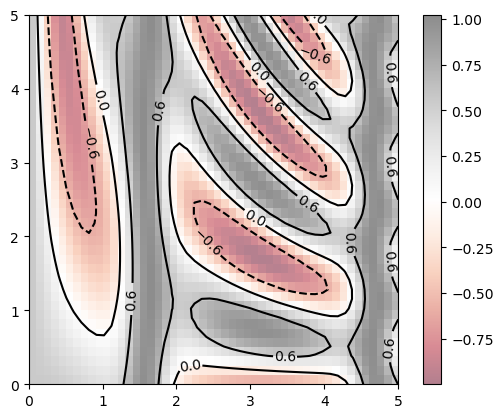

In [41]:
# plt.clabel(plt.contour(), )

contours = plt.contour(X, Y, Z, 3, colors='black')
plt.clabel(contours, inline=True, fontsize=10)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

The combination of these three functions—``plt.contour``, ``plt.contourf``, and ``plt.imshow``—gives nearly limitless possibilities for displaying this sort of three-dimensional data within a two-dimensional plot.
For more information on the options available in these functions, refer to their docstrings.
If you are interested in three-dimensional visualizations of this type of data, see [Three-dimensional Plotting in Matplotlib](04.12-Three-Dimensional-Plotting.ipynb).

🐍 将 plt.contour、plt.contourf 与 plt.imshow 这三个函数组合起来之后，就打开了用二维图画三维数据的无尽可能。

<!--NAVIGATION-->
< [Visualizing Errors](04.03-Errorbars.ipynb) | [Contents](Index.ipynb) | [Histograms, Binnings, and Density](04.05-Histograms-and-Binnings.ipynb) >